# Insight 177 replication

This notebook runs the PyTorch replication for all six markets. It produces both the paper-comparable 2015-2025 out-of-sample results and an expanded-history sensitivity run.

The OOS protocol follows Insight 177: for each Tuesday evaluation date, the model is trained only on the preceding 104 weekly observations, excludes the current Managed Money observation, uses price inputs through the current Tuesday, and scores the prediction only after the realized Managed Money value is available.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from paper_replication import ReplicationConfig, run_replication, MARKETS

DATA_DIR = PROJECT_ROOT / 'data_required'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'derived').mkdir(exist_ok=True)
print(PROJECT_ROOT)

/Users/zhangziyao/Desktop/MSCF_course/semester3/ML capstone/Capstone/paper_replication


## Configuration

`futures_only` is the default Managed Money basis. Change it to `combined` only for a sensitivity run. The first rolling fit uses 1,024 full-batch epochs; later windows warm-start from the previous fit and use 36 epochs.

In [2]:
config = ReplicationConfig(data_dir=DATA_DIR, basis='futures_only', train_weeks=104, seed=7)
config

ReplicationConfig(data_dir=PosixPath('/Users/zhangziyao/Desktop/MSCF_course/semester3/ML capstone/Capstone/paper_replication/data_required'), basis='futures_only', train_weeks=104, hidden_factors=3, first_epochs=1024, rolling_epochs=36, learning_rate=0.01, lambda_w=0.04, lambda_bias=0.01, evaluation_start='2015-01-01', evaluation_end='2025-12-31', seed=7, expanded=False)

## Paper-comparable run

This run retains the two-year warm-up and evaluates forecasts from 2015 through 2025.

In [3]:
paper_run = run_replication(config, expanded=False)
paper_metrics = paper_run['metrics']
paper_metrics

/Users/zhangziyao/Desktop/MSCF_course/semester3/ML capstone/Capstone/paper_replication/src/paper_replication/data.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group[f"x_{horizon}"] = mom / mom.rolling(252, min_periods=252).std().replace(0, np.nan)
/Users/zhangziyao/Desktop/MSCF_course/semester3/ML capstone/Capstone/paper_replication/src/paper_replication/data.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group[f"mom_{horizon}"] = mom
/Users/zhangziyao/Desktop/MSCF_course/semester3/ML capstone/Capstone/paper_repl

r2_oos                  NaN
directional_accuracy    NaN
observations            0.0
dtype: float64

In [4]:
paper_predictions = paper_run['predictions']
paper_predictions.to_csv(OUTPUT_DIR / 'neural_network' / 'model_predictions_paper_window.csv', index=False)
paper_run['weekly_panel'].to_parquet(PROJECT_ROOT / 'outputs' / 'neural_network' / 'weekly_features_paper_window.parquet', index=False)
paper_metrics.to_csv(OUTPUT_DIR / 'neural_network' / 'metrics_paper_window.csv')
paper_predictions.head()

,market,report_week_tuesday,actual_position,mm_std_lag,predicted_y,y,predicted_position_change,actual_position_change,actual_change,predicted_change
0,BRENT,2015-01-06,142286.0,53496.797195,NaN,-1.118602,NaN,NaN,NaN,NaN
6,BRENT,2015-01-13,142751.0,53522.557240,NaN,-0.822994,NaN,NaN,465.0,NaN
12,BRENT,2015-01-20,127801.0,53357.286975,NaN,-0.798238,NaN,NaN,-14950.0,NaN
18,BRENT,2015-01-27,129740.0,53118.270394,NaN,-0.820288,NaN,NaN,1939.0,NaN
24,BRENT,2015-02-03,124499.0,53002.794569,NaN,-0.968031,NaN,NaN,-5241.0,NaN


## Expanded-history run

This run uses all available weekly dates after the same 104-week warm-up. Its metrics should not be compared directly with the published tables unless the date range is restricted.

In [5]:
expanded_run = run_replication(config, expanded=True)
expanded_metrics = expanded_run['metrics']
expanded_metrics

/Users/zhangziyao/Desktop/MSCF_course/semester3/ML capstone/Capstone/paper_replication/src/paper_replication/data.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group[f"x_{horizon}"] = mom / mom.rolling(252, min_periods=252).std().replace(0, np.nan)
/Users/zhangziyao/Desktop/MSCF_course/semester3/ML capstone/Capstone/paper_replication/src/paper_replication/data.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group[f"mom_{horizon}"] = mom
/Users/zhangziyao/Desktop/MSCF_course/semester3/ML capstone/Capstone/paper_repl

r2_oos                  NaN
directional_accuracy    NaN
observations            0.0
dtype: float64

In [6]:
expanded_predictions = expanded_run['predictions']
expanded_predictions.to_csv(OUTPUT_DIR / 'neural_network' / 'model_predictions_expanded.csv', index=False)
expanded_run['weekly_panel'].to_parquet(PROJECT_ROOT / 'outputs' / 'neural_network' / 'weekly_features_expanded.parquet', index=False)
expanded_metrics.to_csv(OUTPUT_DIR / 'neural_network' / 'metrics_expanded.csv')
expanded_predictions.tail()

,market,report_week_tuesday,actual_position,mm_std_lag,predicted_y,y,predicted_position_change,actual_position_change,actual_change,predicted_change
1511,WTI,2017-10-24,239964.0,85998.160088,NaN,-0.692751,NaN,NaN,17830.0,NaN
1517,WTI,2017-10-31,295232.0,85500.823700,NaN,-1.146651,NaN,NaN,55268.0,NaN
1523,WTI,2017-11-07,340269.0,85477.540808,NaN,-0.760516,NaN,NaN,45037.0,NaN
1529,WTI,2017-11-14,372239.0,85853.750173,NaN,-0.377307,NaN,NaN,31970.0,NaN
1535,WTI,2017-11-21,339492.0,86592.007340,NaN,-0.421239,NaN,NaN,-32747.0,NaN


## Diagnostics

The plot compares actual and model-predicted normalized Managed Money positions by market. The paper's published figures use position changes for scoring; this plot is a visual diagnostic for level comovement.

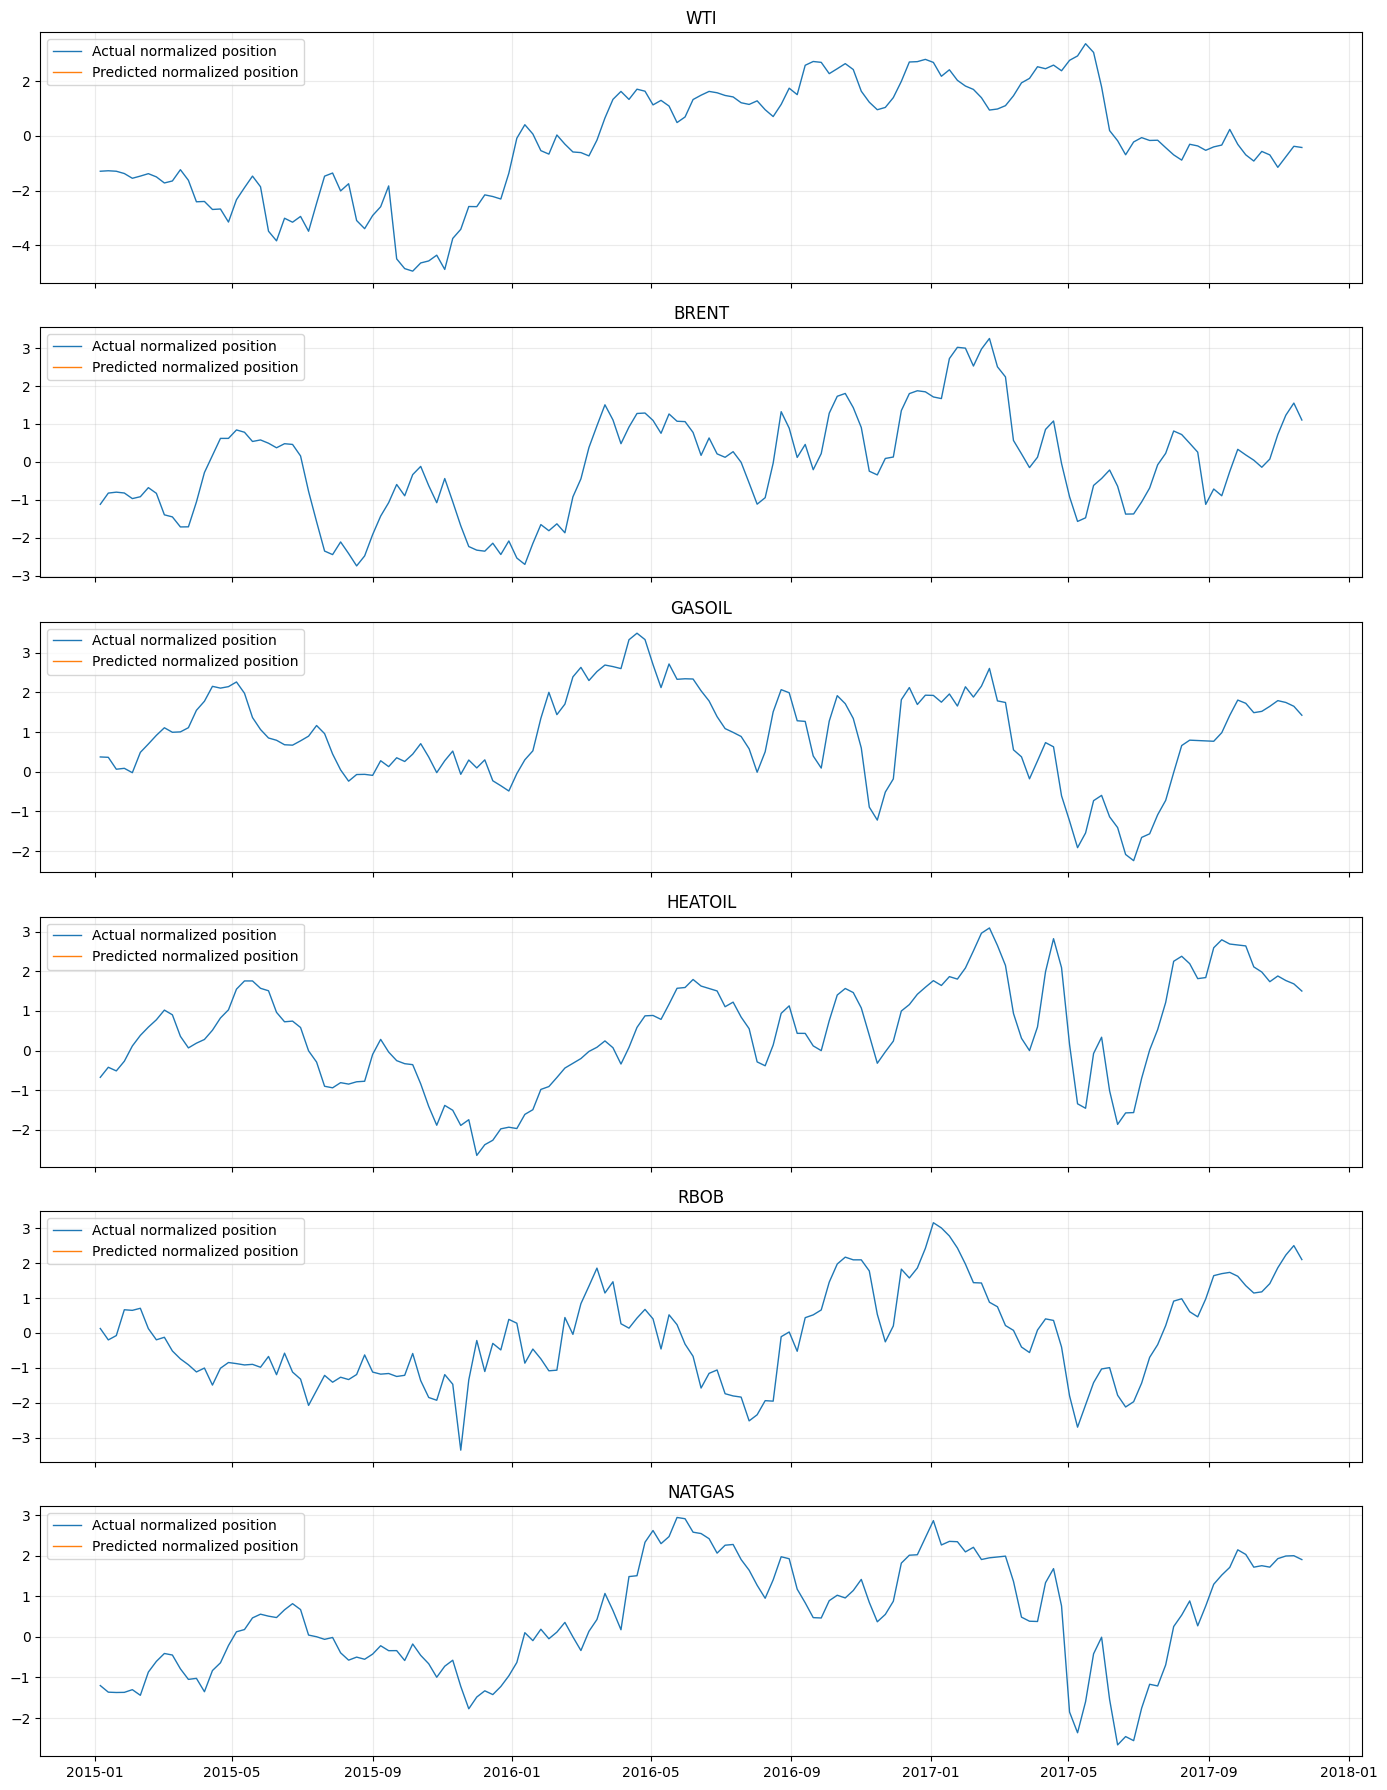

In [7]:
fig, axes = plt.subplots(len(MARKETS), 1, figsize=(14, 18), sharex=True)
for axis, market in zip(axes, MARKETS):
    subset = paper_predictions.loc[paper_predictions['market'].eq(market)]
    axis.plot(subset['report_week_tuesday'], subset['y'], label='Actual normalized position', linewidth=1)
    axis.plot(subset['report_week_tuesday'], subset['predicted_y'], label='Predicted normalized position', linewidth=1)
    axis.set_title(market)
    axis.grid(alpha=0.25)
    axis.legend(loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'neural_network' / 'figures_model_vs_actual_levels.png', dpi=160)
plt.show()

## Checks to record

Compare the paper-window metrics with Insight 177's reported cumulative performance. Differences can arise from the source data vintage, futures roll reconstruction, futures-only versus combined COT basis, missing-settlement handling, and exact implementation details of the regularized bias. Keep the expanded-history results separate from the paper-comparable results.